### Постановка задачи классификации IC50 > median
Цель: предсказать, превышает ли значение `IC50` медианное значение по выборке.
Будут протестированы 3 модели: Random Forest, Gradient Boosting и SVM на данных с выбросами и без них.

In [3]:
!pip install optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.5 MB/s eta 0:00:00


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Модели и метрики
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score, cross_validate
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, mean_squared_error, r2_score, root_mean_squared_error,roc_auc_score
)

# Сторонние библиотеки для градиентного бустинга и оптимизации
import xgboost as xgb
import lightgbm as lgb
import optuna

In [5]:
# Load the dataset
file_path = '/content/cleaned_molecular_data.csv'
df = pd.read_csv(file_path)

# Display basic information
print("Dataset Shape:", df.shape)
display(df.head())
print(df.info())

Dataset Shape: (966, 214)


,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,is_outlier
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,3,0,1
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,3,0,1
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,3,0,1
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,4,0,1
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 966 entries, 0 to 965
Columns: 214 entries, IC50, mM to is_outlier
dtypes: float64(107), int64(107)
memory usage: 1.6 MB
None


In [6]:
# 1. Подготовка меток (классификация по медиане)
median_ic50 = df['IC50, mM'].median()
df['target_class'] = (df['IC50, mM'] > median_ic50).astype(int)

# 2. Подготовка выборок
# А) С выбросами
X_with = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI', 'is_outlier', 'target_class'])
y_with = df['target_class']

# Б) Без выбросов
df_no_outliers = df[df['is_outlier'] == 1].copy()
X_no = df_no_outliers.drop(columns=['IC50, mM', 'CC50, mM', 'SI', 'is_outlier', 'target_class'])
y_no = df_no_outliers['target_class']

print(f"Медиана IC50: {median_ic50:.4f}")

Медиана IC50: 45.2228


In [7]:
def evaluate_models(X, y, title):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Масштабирование (важно для SVM)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    models = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42),
        'SVM': SVC(random_state=42)
    }

    results = []
    for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds)
        results.append({'Model': name, 'Accuracy': acc, 'F1': f1})

    res_df = pd.DataFrame(results)
    print(f"\nРезультаты для: {title}")
    display(res_df)
    return res_df

results_with = evaluate_models(X_with, y_with, "Данные С ВЫБРОСАМИ")
results_no = evaluate_models(X_no, y_no, "Данные БЕЗ ВЫБРОСОВ")


Результаты для: Данные С ВЫБРОСАМИ


,Model,Accuracy,F1
0,Random Forest,0.731959,0.729167
1,Gradient Boosting,0.706186,0.701571
2,SVM,0.726804,0.728205



Результаты для: Данные БЕЗ ВЫБРОСОВ


,Model,Accuracy,F1
0,Random Forest,0.782609,0.784946
1,Gradient Boosting,0.782609,0.780220
2,SVM,0.760870,0.765957


модели классификации показывают себя заметно лучше на данных без **выбросов**

In [8]:
X_tr_raw, X_te_raw, y_tr_raw, y_te_raw = train_test_split(X_no, y_no, test_size=0.2, random_state=42, stratify=y_no)
rf_unscaled = RandomForestClassifier(random_state=42)
rf_unscaled.fit(X_tr_raw, y_tr_raw)
preds_unscaled = rf_unscaled.predict(X_te_raw)
acc_unscaled = accuracy_score(y_te_raw, preds_unscaled)
f1_unscaled = f1_score(y_te_raw, preds_unscaled)

print("Baseline RF Performance on Unscaled Data (No Outliers):")
print(f"Accuracy: {acc_unscaled:.4f}")
print(f"F1-Score: {f1_unscaled:.4f}")
print("\nDetailed Report:")
print(classification_report(y_te_raw, preds_unscaled))

Baseline RF Performance on Unscaled Data (No Outliers):
Accuracy: 0.7826
F1-Score: 0.7849

Detailed Report:
              precision    recall  f1-score   support

           0       0.79      0.77      0.78        92
           1       0.78      0.79      0.78        92

    accuracy                           0.78       184
   macro avg       0.78      0.78      0.78       184
weighted avg       0.78      0.78      0.78       184



/tmp/ipykernel_39975/2470500373.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='magma')


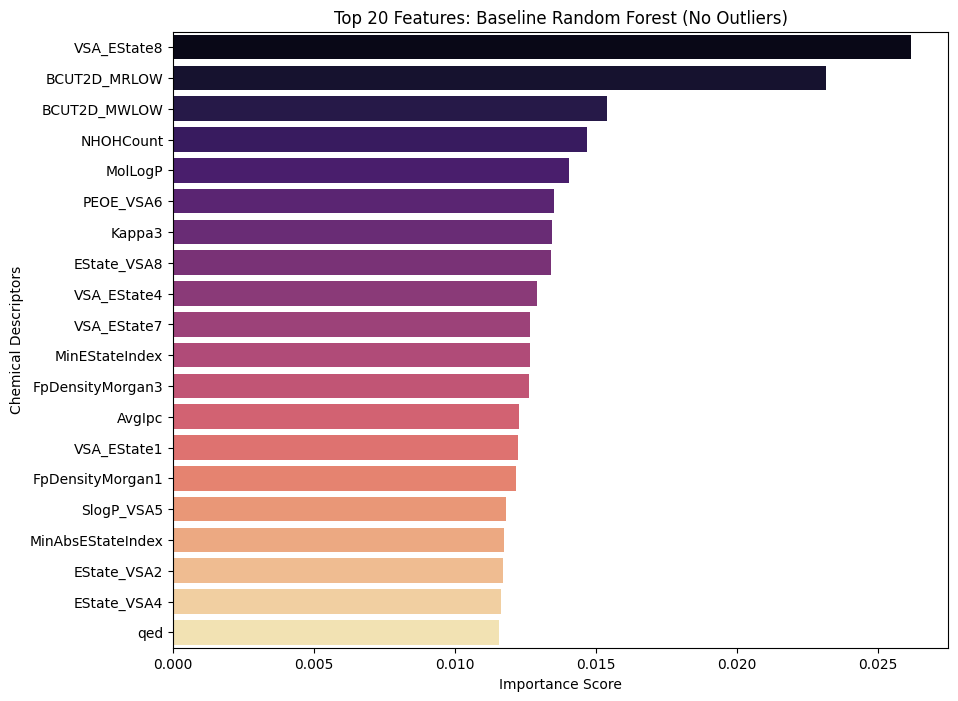

Top 10 Baseline Features:


,Feature,Importance
103,VSA_EState8,0.026193
25,BCUT2D_MRLOW,0.023151
19,BCUT2D_MWLOW,0.015405
107,NHOHCount,0.014670
123,MolLogP,0.014036
57,PEOE_VSA6,0.013507
45,Kappa3,0.013459
93,EState_VSA8,0.013404
99,VSA_EState4,0.012908
102,VSA_EState7,0.012665


In [ ]:
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_no, y_no, test_size=0.2, random_state=42, stratify=y_no
)

rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_train_base, y_train_base)
importances = rf_base.feature_importances_
feature_names = X_no.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='magma')
plt.title('Top 20 Features: Baseline Random Forest (No Outliers)')
plt.xlabel('Importance Score')
plt.ylabel('Chemical Descriptors')
plt.show()

print("Top 10 Baseline Features:")
display(importance_df.head(10))

### Оптимизация Random Forest для классификации (Данные без выбросов)
Мы будем использовать Optuna для максимизации метрики F1-score на кросс-валидации.

In [ ]:
def objective_rf_cls(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 400),
        'max_depth': trial.suggest_int('max_depth', 2, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 15),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': 42
    }

    model = RandomForestClassifier(**params)

    skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
    cv_f1 = cross_val_score(model, X_tr_raw, y_tr_raw, cv=skf, scoring='f1').mean()
    model.fit(X_tr_raw, y_tr_raw)
    test_preds = model.predict(X_te_raw)
    test_f1 = f1_score(y_te_raw, test_preds)

    gap = abs(cv_f1 - test_f1)
    penalty_factor = 0.1

    return cv_f1 - penalty_factor * gap

study_rf_cls = optuna.create_study(direction='maximize')

default_params = {
    'n_estimators': 100,
    'max_depth': 15,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'max_features': 'sqrt'
}
study_rf_cls.enqueue_trial(default_params)

study_rf_cls.optimize(objective_rf_cls, n_trials=2)#200 для реального поиска

print("Best RF Parameters:", study_rf_cls.best_params)
print("Best Penalized F1 Score:", study_rf_cls.best_value)

[I 2026-05-23 20:07:53,450] A new study created in memory with name: no-name-ff791c9c-a40a-4bcb-984e-8793731fb42c
[I 2026-05-23 20:07:58,892] Trial 0 finished with value: 0.6412560943779056 and parameters: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6412560943779056.
[I 2026-05-23 20:08:06,772] Trial 1 finished with value: 0.6289257904118586 and parameters: {'n_estimators': 323, 'max_depth': 25, 'min_samples_split': 13, 'min_samples_leaf': 3, 'max_features': 'log2'}. Best is trial 0 with value: 0.6412560943779056.


Best RF Parameters: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Best Penalized F1 Score: 0.6412560943779056


In [10]:
best_params= {'n_estimators': 41, 'max_depth': 16, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt'}

### Финальная оценка оптимизированной модели
Оценим модель с лучшими параметрами на отложенной тестовой выборке.

Baseline RF Performance on Unscaled Data (No Outliers):
Accuracy: 0.7880
F1-Score: 0.7892
ROC-AUC: 0.7880
Classification Report (Optimized RF - No Scaling):
              precision    recall  f1-score   support

           0       0.79      0.78      0.79        92
           1       0.78      0.79      0.79        92

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.79      0.79      0.79       184



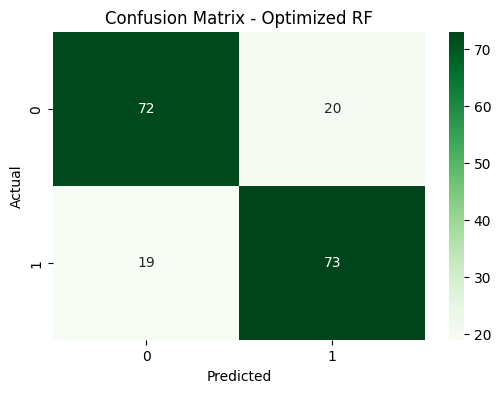

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_no, y_no, test_size=0.2, random_state=42, stratify=y_no)

#best_rf_cls = RandomForestClassifier(**study_rf_cls.best_params, random_state=42)# закоментировать если обучаемся из готовых параетров
best_rf_cls = RandomForestClassifier(**best_params, random_state=42) #если оубчаемся из готовых параметров, раскоментировать
best_rf_cls.fit(X_train, y_train)

final_preds = best_rf_cls.predict(X_test)
acc_unscaled = accuracy_score(y_test, final_preds)
f1_unscaled = f1_score(y_test, final_preds)
roc_auc = roc_auc_score(y_test, final_preds)
print("Baseline RF Performance on Unscaled Data (No Outliers):")
print(f"Accuracy: {acc_unscaled:.4f}")
print(f"F1-Score: {f1_unscaled:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print("Classification Report (Optimized RF - No Scaling):")
print(classification_report(y_test, final_preds))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, final_preds), annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Optimized RF')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Очевидно что для классификации лучше подходжят данные без выбросов

In [ ]:


def evaluate_models_with_auc(X, y, title):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Масштабирование (важно для SVM)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    models = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42),
        'SVM': SVC(random_state=42, probability=True) # Enable probability for ROC AUC
    }

    results = []
    for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds)

        # Calculate ROC AUC
        if hasattr(model, "predict_proba"):
            preds_proba = model.predict_proba(X_test_scaled)[:, 1]
            roc_auc = roc_auc_score(y_test, preds_proba)
        else:
            roc_auc = np.nan # Not applicable if predict_proba is not available

        results.append({'Model': name, 'Accuracy': acc, 'F1': f1, 'ROC AUC': roc_auc})

    res_df = pd.DataFrame(results)
    print(f"\nРезультаты для: {title}")
    display(res_df)
    return res_df

print("--- Re-evaluating models with ROC AUC ---")
results_with_auc = evaluate_models_with_auc(X_with, y_with, "Данные С ВЫБРОСАМИ (с ROC AUC)")
results_no_auc = evaluate_models_with_auc(X_no, y_no, "Данные БЕЗ ВЫБРОСОВ (с ROC AUC)")